(-0.5, 359.5, 359.5, -0.5)

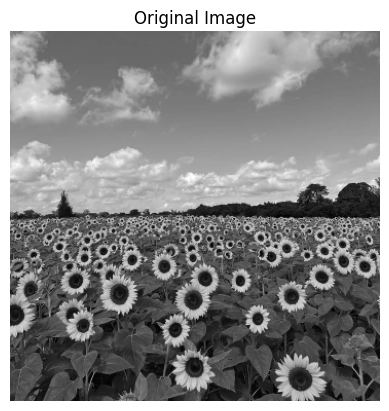

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread('images/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
im = im.astype(np.float32) / 255.0

fig, ax = plt.subplots()
ax.imshow(im, cmap='gray')
ax.set_title('Original Image')
ax.axis('off')

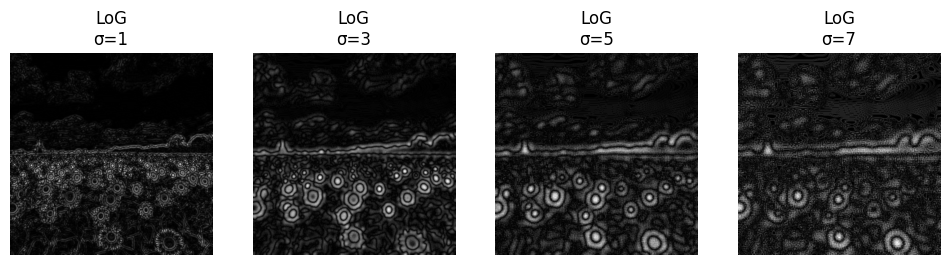

In [14]:
sigmas = [1, 3, 5, 7]
logs = []

for sigma in sigmas:
    blur = cv.GaussianBlur(im, (0, 0), sigma) 
    log = cv.Laplacian(blur, cv.CV_32F, ksize=5)
    log_norm = sigma**2 * np.abs(log) #cause we want to scale and casue we just want blobs, not bright or dark
    logs.append(log_norm)

fig, ax = plt.subplots(1, 4, figsize=(12, 4))
for i in range(4):
    ax[i].imshow(logs[i], cmap='gray')
    ax[i].set_title(f'LoG\nσ={sigmas[i]}')
    ax[i].axis('off')
plt.show()

In [ ]:
from skimage.feature import peak_local_max

# Find local maxima in 3D scale space
coordinates = peak_local_max(scale_space, threshold_abs=0.03, footprint=np.ones((7,7,3)))

# Extract parameters
blobs = []
for y, x, s in coordinates:
    sigma = sigmas[s]
    r = np.sqrt(2) * sigma
    blobs.append((x, y, r))

# Sort by radius to get the largest blobs
blobs = sorted(blobs, key=lambda b: b[2], reverse=True)
largest_blobs = blobs[:5]  # report top 5

# Draw detected circles
output = im.copy()
for (x, y, r) in blobs:
    cv.circle(output, (int(x), int(y)), int(r), (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Detected Sunflower Blobs")
plt.axis("off")
plt.show()

# Print largest circles' parameters
print("Range of sigma values used:", sigma_values)
print("Top 5 largest circles (x, y, radius):")
for b in largest_blobs:
    print(b)

In [ ]:
# Generation of a Noisy Point Set Conforming to a Line and a Circle
import numpy as np
from scipy.optimize import minimize  # (kept if needed later)
from scipy import linalg  # (kept if needed later)
import matplotlib.pyplot as plt
# import tikzplotlib  # Optional: enable if you need LaTeX export and package is installed

# np.random.seed(0)  # Uncomment for reproducibility
N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Center

# --- Circle points (noisy) ---
s = r / 16
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x = x0_gt + (r + n) * np.cos(t)
y = y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# --- Line points (noisy) ---
s = 1.0
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# --- All points ---
X = np.vstack((X_circ, X_line))

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label="Line")
ax.scatter(X_circ[:, 0], X_circ[:, 1], label="Circle")

circle_gt = plt.Circle((x0_gt, y0_gt), r, color="g", fill=False, label="Ground truth circle")
ax.add_patch(circle_gt)
ax.plot([x0_gt], [y0_gt], "+", color="g")

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
ax.plot(x_, y_, color="m", label="Ground truth line")
ax.legend()
plt.show()